In [2]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool
from dotenv import load_dotenv
import requests
import os

In [3]:
load_dotenv()
os.environ["LANGSMITH_PROJECT"] = "basic-chatbot-demo"
STOCK_API_KEY = os.getenv("STOCK_API_KEY")

In [4]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [5]:
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [6]:
# Tools:-
search_tool = DuckDuckGoSearchRun()

In [7]:
@tool
def calculator(first_number: float, second_number: float, operation: str) -> dict:
    """
    Simple calculator tool that performs basic arithmetic operations on two numbers
    
    Args:
        first_number: First number
        second_number: Second number
        operation: Operation to perform (add, subtract, multiply, divide)
    
    Returns:
        Dictionary with result of the operation
    """
    
    try:
        if operation == "add":
            result = first_number + second_number
        elif operation == "subtract":
            result = first_number - second_number
        elif operation == "multiply":
            result = first_number * second_number
        elif operation == "divide":
            if second_number == 0:
                return {"error": "Division by zero is not allowed"}
            result = first_number / second_number
        else:
            return {"error": f"Unsupported operation: {operation}"}
    except Exception as e:
        return {"error": str(e)}
    return {
        "first_number": first_number, 
        "second_number": second_number, 
        "operation": operation, 
        "result": result
    }

In [8]:
@tool
def get_stock_price(symbol: str) -> dict:
    """
    Fetch latest stock price for a given symbol (e.g. 'AAPL', 'TSLA') 
    using Alpha Vantage with API key in the URL.
    """
    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey={STOCK_API_KEY}"
    response = requests.get(url)
    return response.json()

In [9]:
tools = [search_tool, calculator, get_stock_price]
llm_with_tools = llm.bind_tools(tools)

In [10]:
# Chat Node
def chat_node(state: ChatState):
    messages = state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

# Tool Node
tool_node = ToolNode(tools)

In [12]:
graph = StateGraph(ChatState)
checkpointer = MemorySaver()

graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)

graph.add_edge(START, "chat_node")
graph.add_conditional_edges("chat_node", tools_condition)
graph.add_edge("tools", "chat_node")

chatbot = graph.compile(checkpointer=checkpointer)

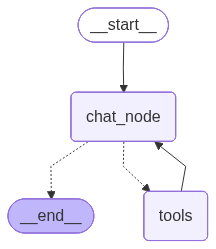

In [13]:
chatbot

### Normal Chat messages:

In [14]:
initial_state = {
    "messages": [
        HumanMessage(content="What is the capital of India?")
    ]
}

result = chatbot.invoke(initial_state)
result["messages"]

[HumanMessage(content='What is the capital of India?', additional_kwargs={}, response_metadata={}, id='64004a0b-4963-4432-b6e1-a363ff4864d3'),
 AIMessage(content='The capital of India is New Delhi.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 42, 'total_tokens': 51, 'completion_time': 0.013084035, 'completion_tokens_details': None, 'prompt_time': 0.00369185, 'prompt_tokens_details': None, 'queue_time': 0.055045679, 'total_time': 0.016775885}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d9feb-bc5b-7fe3-9ffa-6e11e186caa5-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 42, 'output_tokens': 9, 'total_tokens': 51})]

In [22]:
thread_id = '1'

while True:
    user_input = input("You: ")
    print("User:", user_input)
    
    if user_input.strip().lower() in ["exit", "quit", "bye"]:
        break
    
    config = {"configurable": {"thread_id": thread_id}}
    response = chatbot.invoke({"messages": [HumanMessage(content=user_input)]}, config=config)
    print("Bot:", response["messages"][-1].content)
    print()

User: Hello my name is Krish
Bot: Nice to meet you, Krish. It's a pleasure to chat with you. How's your day going so far?

User: Add 19 and 10
Bot: 19 + 10 = 29

User: add 1006 to the result
Bot: We had 29 as the previous result. 

29 + 1006 = 1035

User: divide result by 7
Bot: We had 1035 as the previous result.

1035 ÷ 7 = 148 (with a remainder of 1, but if we're looking for a decimal result) 
1035 ÷ 7 = 148.14 (rounded to two decimal places)

User: multiply by 0, then add 50, then add 70, then multiply by 2
Bot: Let's follow the steps:

1. Multiply 148.14 by 0:
148.14 × 0 = 0

2. Add 50:
0 + 50 = 50

3. Add 70:
50 + 70 = 120

4. Multiply by 2:
120 × 2 = 240

The final result is 240.

User: bye


In [21]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='Hello', additional_kwargs={}, response_metadata={}, id='71dd528b-6d69-49d4-8236-0b526661ac76'), AIMessage(content='Hello. How can I help you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 36, 'total_tokens': 46, 'completion_time': 0.023372652, 'completion_tokens_details': None, 'prompt_time': 0.001222206, 'prompt_tokens_details': None, 'queue_time': 0.15952686, 'total_time': 0.024594858}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d9ff9-2634-78e0-8212-9c485ca4dc8f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 10, 'total_tokens': 46}), HumanMessage(content='My name is nitish', additional_kwargs={}, response_metadata={}, id='3777381f-699d-4b0f-b762-378ebce84171'), AIMessage(c

### Tool Chat messages:

In [16]:
out = chatbot.invoke({"messages": [HumanMessage(content="Hello, My name is Krish")]}, config={"configurable": {"thread_id": "1"}})
print(out["messages"][-1].content)

Hello Krish, it's nice to meet you. Is there something I can help you with or would you like to chat?


In [18]:
out = chatbot.invoke({"messages": [HumanMessage(content="What is 2*3?")]}, config={"configurable": {"thread_id": "1"}})
print(out["messages"][-1].content)

The result of 2*3 is 6.


In [19]:
out = chatbot.invoke({"messages": [HumanMessage(content="What is the stock price of apple?")]}, config={"configurable": {"thread_id": "1"}})
print(out["messages"][-1].content)

The current stock price of Apple (AAPL) is $270.23.


In [20]:
out = chatbot.invoke({"messages": [HumanMessage(content="What is the stock price of salesforce? How much it would cost to buy 10 shares?")]}, config={"configurable": {"thread_id": "1"}})
print(out["messages"][-1].content)

The current stock price of Salesforce (CRM) is $182.14. It would cost $1821.40 to buy 10 shares.
